# Customer Churn Prediction — Random Forest
End-to-end notebook: EDA, preprocessing, model training, hyperparameter tuning, and evaluation.

## 1. Imports

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

sns.set_style('whitegrid')

## 2. Load data

In [35]:

df = pd.read_csv("data/customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [37]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

## 3. Clean data
`TotalCharges` has some blank strings that need converting to numeric, then the resulting NaNs are filled using `MonthlyCharges * tenure`.

In [39]:
df['TotalCharges'].value_counts()  # some blank strings present

TotalCharges
          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [40]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 4. Exploratory Data Analysis

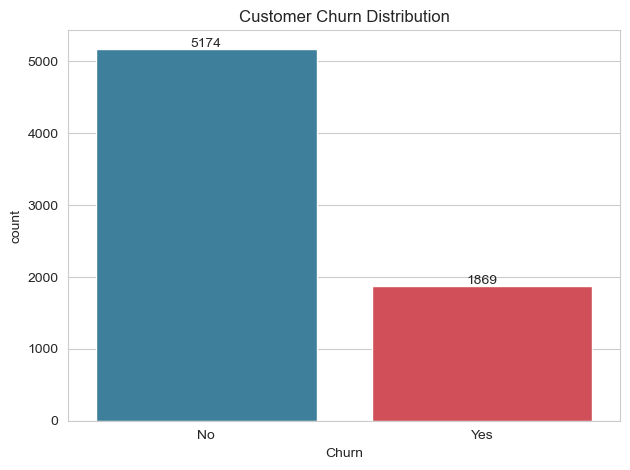

In [41]:
ax = sns.countplot(x='Churn', data=df, hue='Churn', legend=False, palette=['#2E86AB','#E63946'])
plt.title('Customer Churn Distribution')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+30), ha='center')
plt.tight_layout()
plt.show()

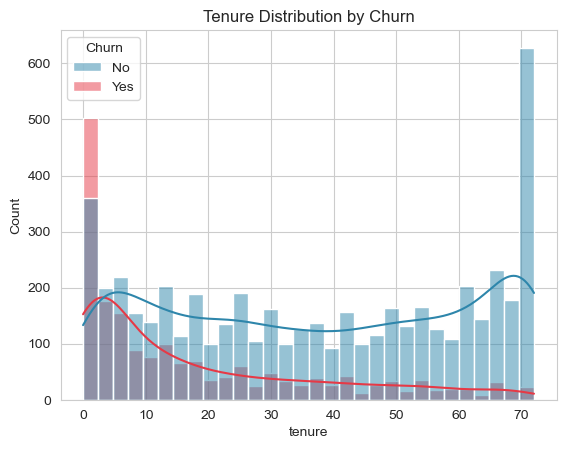

In [42]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette=['#2E86AB','#E63946'])
plt.title('Tenure Distribution by Churn')
plt.show()

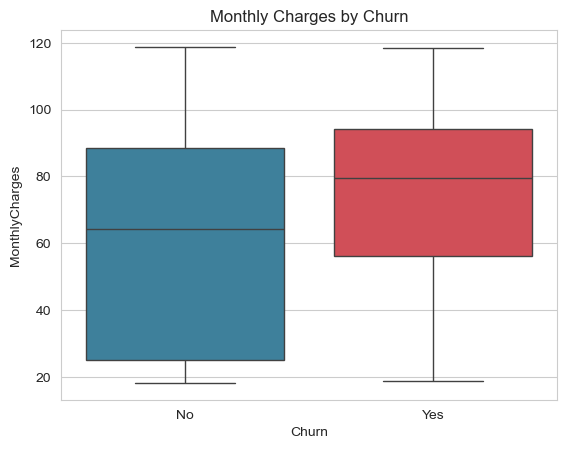

In [43]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', legend=False, palette=['#2E86AB','#E63946'])
plt.title('Monthly Charges by Churn')
plt.show()

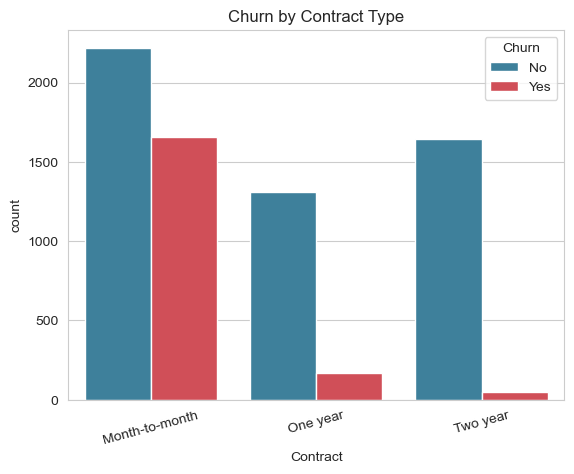

In [44]:
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#2E86AB','#E63946'])
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

## 5. Encode categorical features

In [45]:
df.drop('customerID', axis=1, inplace=True)

In [46]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col].astype(str))
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


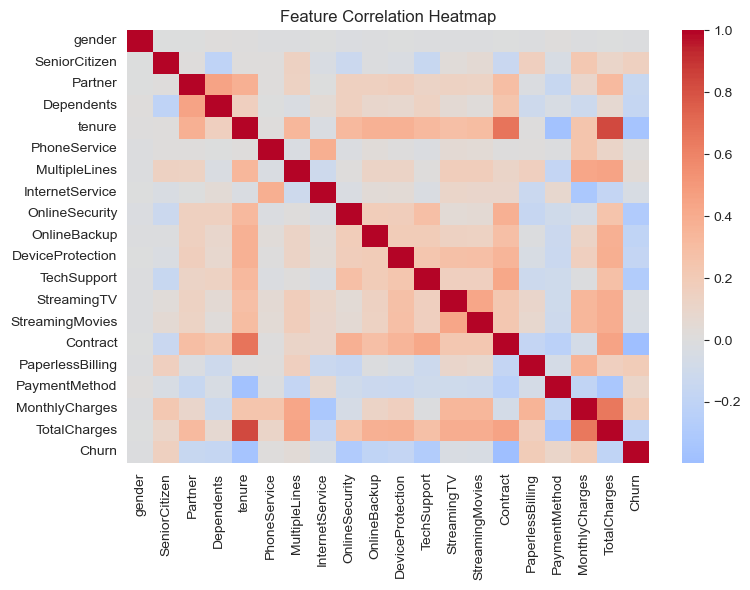

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 6. Train / test split

In [48]:
x = df.drop('Churn', axis=1)
y = df['Churn']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## 7. Baseline model

In [49]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)

0.794889992902768

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## 8. Compare different `n_estimators`

In [51]:
n_values = [10, 50, 100, 200, 500, 900, 1000]
accuracies = []
for n in n_values:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    m.fit(x_train, y_train)
    p = m.predict(x_test)
    accuracies.append(accuracy_score(y_test, p))

pd.DataFrame({'Number of trees': n_values, 'Accuracy': accuracies})

,Number of trees,Accuracy
0,10,0.782115
1,50,0.793471
2,100,0.794890
3,200,0.799148
4,500,0.796309
5,900,0.797729
6,1000,0.798439


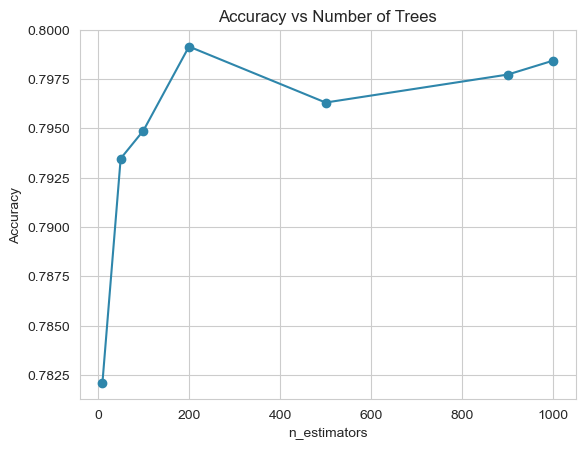

In [52]:
plt.plot(n_values, accuracies, marker='o', color='#2E86AB')
plt.title('Accuracy vs Number of Trees')
plt.xlabel('n_estimators'); plt.ylabel('Accuracy')
plt.show()

## 9. Hyperparameter tuning with GridSearchCV

In [53]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
}
model2 = RandomForestClassifier(random_state=0)
grid_search = GridSearchCV(estimator=model2, param_grid=param_grid, cv=3, n_jobs=-1)
grid_search.fit(x_train, y_train)
grid_search.best_estimator_

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 10. Final tuned model

In [54]:
model3 = RandomForestClassifier(**grid_search.best_params_, random_state=0)
model3.fit(x_train, y_train)
y_pred_tuned = model3.predict(x_test)
accuracy_score(y_test, y_pred_tuned)

0.8090844570617459

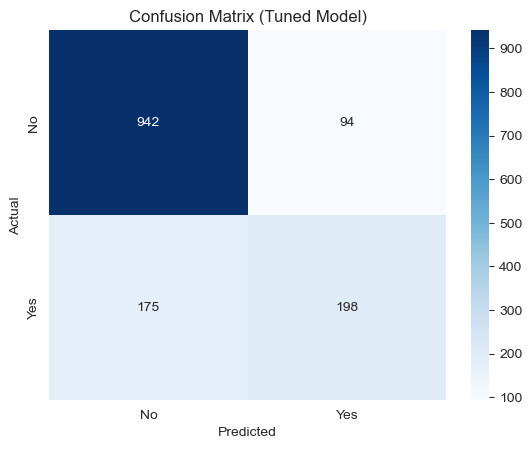

In [55]:
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title('Confusion Matrix (Tuned Model)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

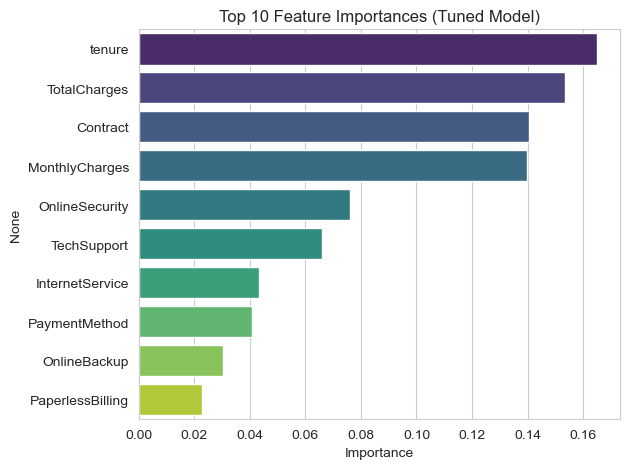

In [56]:
importances = pd.Series(model3.feature_importances_, index=x.columns).sort_values(ascending=False).head(10)
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False, palette='viridis')
plt.title('Top 10 Feature Importances (Tuned Model)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 11. Save the trained model

In [57]:
joblib.dump(model3, 'model.pkl')

['model.pkl']

## 12. Overall churn rate

In [58]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)
# 0 : customers who have not churned
# 1 : customers who have churned

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64
